In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score


# -----------------------------
# 1. Load metadata (cells as index)
# -----------------------------
meta_path = "../wang_2024/cell_meta_data_CD8.csv"
meta = pd.read_csv(meta_path, index_col=0)
assert "cancer_reactive_per_cell_CD8" in meta.columns, "Response column missing"

In [2]:
adt_values_path = "../wang_2024/data_from_rds/adt_values.csv"
adt = pd.read_csv(adt_values_path, index_col=0)  # rows = proteins, cols = cell IDs

# Transpose → rows = cells, columns = proteins
X = adt.T

# Ensure cell IDs match metadata
common_cells = meta.index.intersection(X.index)
num_removed = len(meta) - len(common_cells)
num_remaining = len(common_cells)

print(f"Number of cells in metadata not found in ADT data and removed: {num_removed}")
print(f"Number of cells remaining for analysis: {num_remaining}")


# Subset both X and y
X = X.loc[common_cells]
y = meta.loc[common_cells, "cancer_reactive_per_cell_CD8"]

Number of cells in metadata not found in ADT data and removed: 56482
Number of cells remaining for analysis: 216915


In [3]:
print(y.value_counts())

cancer_reactive_per_cell_CD8
0    209475
1      7440
Name: count, dtype: int64


split data

In [4]:
# First split: train vs temp (validation+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: validation vs test (splitting the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)


(151840, 106) (32537, 106) (32538, 106)


In [5]:
print(y.value_counts())

cancer_reactive_per_cell_CD8
0    209475
1      7440
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# -----------------------------
# 5. Fit LASSO
# -----------------------------
lasso = Lasso(alpha=0.0001, max_iter=5000)  # alpha = regularization strength
lasso.fit(X_scaled, y_train)




c:\Users\linde\anaconda3\envs\sc_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.284e+00, tolerance: 5.033e-01
  model = cd_fast.enet_coordinate_descent(


,alpha,1e-05
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,5000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [20]:
# ---- Validation ----

# Scale validation data using the same scaler
X_val_scaled = scaler.transform(X_val)

# Predict
y_val_pred = lasso.predict(X_val_scaled)

# Evaluate
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("MSE:", mean_squared_error(y_val, y_val_pred))
print("R²:", r2_score(y_val, y_val_pred))

y_val_binary = (y_val > 0.5).astype(int)
y_val_pred_binary = (y_val_pred > 0.5).astype(int)
from sklearn.metrics import accuracy_score
y_val_pred_binary = pd.Series(y_val_pred_binary, index=y_val.index)


print(y_val_binary.value_counts())
print(y_val_pred_binary.value_counts())
acc = accuracy_score(y_val_binary, y_val_pred_binary)
print("Validation Accuracy:", acc)


MAE: 0.07284968890022016
MSE: 0.030546330914617493
R²: 0.08568906571061274
cancer_reactive_per_cell_CD8
0    31411
1     1126
Name: count, dtype: int64
0    32537
Name: count, dtype: int64
Validation Accuracy: 0.9653932446138243


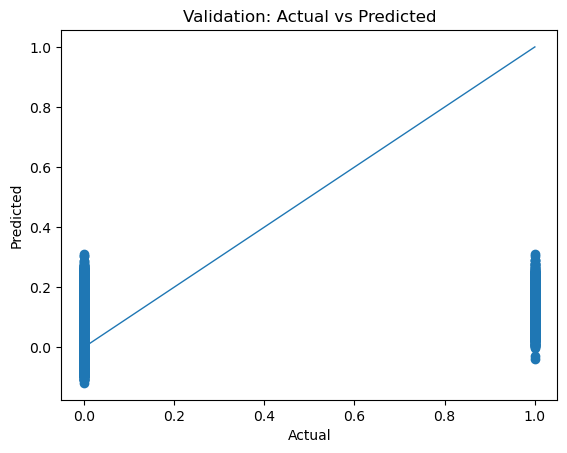

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_val, y_val_pred)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         linewidth=1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Validation: Actual vs Predicted")
plt.show()

In [19]:
coeffs = pd.Series(lasso.coef_, index=X.columns)
important = coeffs[coeffs != 0].sort_values(key=abs, ascending=False)

print("\nProteins selected by LASSO:")
print(important)


Proteins selected by LASSO:
AC-CD38      0.034464
AC-OX40     -0.018521
AC-IgG4      0.014123
AC-CD138    -0.013740
AC-CX3CR1    0.013487
               ...   
AC-TIGIT    -0.000173
AC-CD103    -0.000148
AC-CD305     0.000139
AC-CXCR3    -0.000123
AC-CCR6     -0.000091
Length: 102, dtype: float64
